<a href="https://colab.research.google.com/github/syedjunaid2017/Stock-Price-Prediction/blob/main/Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [2]:
stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
stock.head()

/tmp/ipython-input-3829414648.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
2015-01-05,23.532713,24.064276,23.346667,23.984541,257142000
2015-01-06,23.534941,23.794077,23.173920,23.596956,263188400
2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
2015-01-08,24.781897,24.839483,24.075361,24.192749,237458000


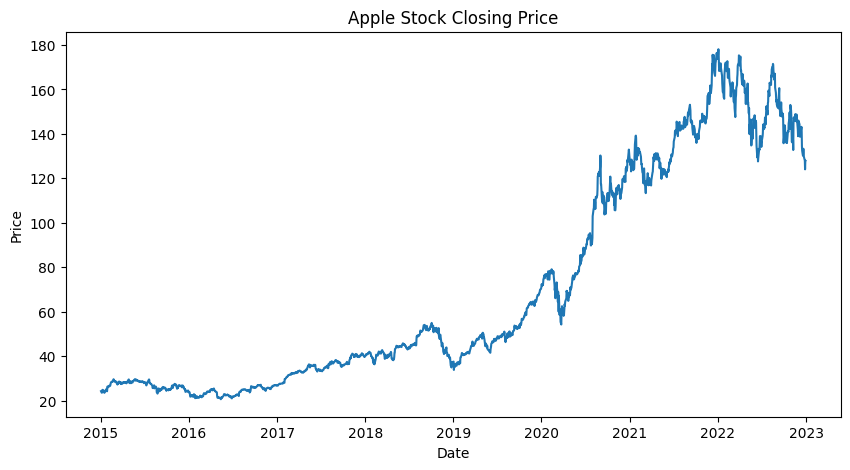

In [3]:
plt.figure(figsize=(10,5))
plt.plot(stock['Close'])
plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [4]:
data = stock['Close'].values
data = data.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [5]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [6]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0232
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.3955e-04
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.7359e-04
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.2166e-04
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.3622e-04
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.1643e-04
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.5100e-04
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.0739e-04
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.9100e-04
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.9061e-04


In [9]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1,1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


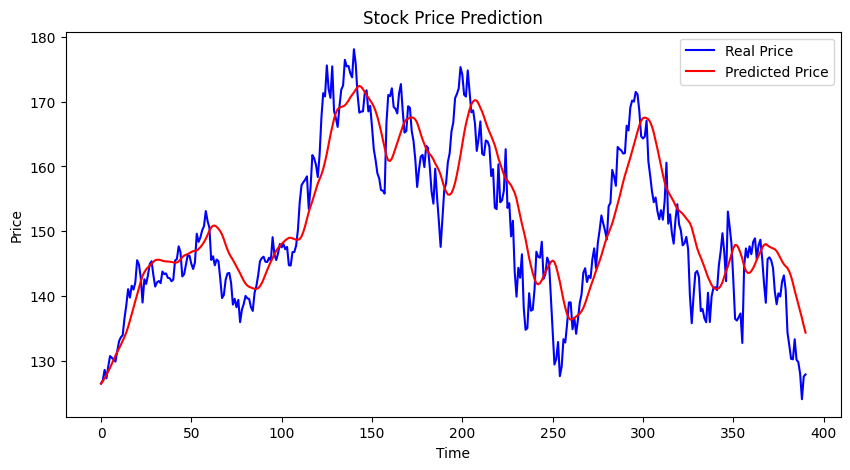

In [10]:
real_prices = scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(10,5))
plt.plot(real_prices, color='blue', label='Real Price')
plt.plot(predictions, color='red', label='Predicted Price')
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [11]:
model.save("stock_price_model.h5")